# Section 1 — Data Loading & Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings_import = __import__('warnings')
warnings_import.filterwarnings('ignore')

In [2]:


# Load all 4 files correctly using raw strings (r'')
emp = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\HR-Analytics\employee_data.csv', encoding='utf-8-sig')
survey = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\HR-Analytics\employee_engagement_survey_data.csv')

# Fixed the name swap here:
training = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\HR-Analytics\training_and_development_data.csv')
recruit = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\HR-Analytics\recruitment_data.csv')


In [3]:
# Rename join keys to match
survey.rename(columns={'Employee ID': 'EmpID'}, inplace=True)
training.rename(columns={'Employee ID': 'EmpID'}, inplace=True)


In [4]:
# Clean employee table
emp.drop_duplicates(inplace=True)
emp['ExitDate'] = pd.to_datetime(emp['ExitDate'], errors='coerce')
emp['StartDate'] = pd.to_datetime(emp['StartDate'], errors='coerce', dayfirst=True)
emp['DOB'] = pd.to_datetime(emp['DOB'], errors='coerce', dayfirst=True)


In [5]:
# Create derived columns
emp['Attrition_Flag'] = emp['EmployeeStatus'].apply(
    lambda x: 1 if str(x).strip().lower() == 'terminated' else 0)


In [6]:
import datetime
emp['Age'] = (datetime.datetime.now() - emp['DOB']).dt.days // 365

emp['Age_Group'] = pd.cut(emp['Age'],
    bins=[20,30,40,50,70],
    labels=['20-30','31-40','41-50','50+'])

emp['Tenure_Years'] = ((pd.Timestamp.now() - emp['StartDate'])
                        .dt.days // 365)


In [7]:
# Merge employee + survey + training
df = emp.merge(survey, on='EmpID', how='left')
df = df.merge(training, on='EmpID', how='left')


In [9]:
df.head()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,3427,Uriah,Bridges,2019-09-20,NaT,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,3428,Paula,Small,2023-02-11,NaT,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,3429,Edward,Buck,2018-12-10,NaT,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3430,Michael,Riordan,2021-06-21,NaT,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,3431,Jasmine,Onque,2019-06-29,NaT,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


In [10]:
recruit.head()

,Applicant ID,Application Date,First Name,Last Name,Gender,Date of Birth,Phone Number,Email,Address,City,State,Zip Code,Country,Education Level,Years of Experience,Desired Salary,Job Title,Status
0,1001,03-Jun-23,Scott,Sheppard,Male,31-08-1992,421-429-7655x39421,perezjanet@example.org,597 Smith Point,Hollandfort,NV,57588,Micronesia,High School,8,60103.21,Chief Technology Officer,Interviewing
1,1002,15-May-23,Stanley,Lewis,Male,29-04-1965,+1-451-574-5308x1681,grossmark@example.com,8116 Stuart Loop,Port Margaretfurt,TN,14726,Greenland,Bachelor's Degree,17,64575.84,"Designer, furniture",Rejected
2,1003,04-Aug-23,Javier,Li,Female,10-03-1973,(858)901-5499,katiemaldonado@example.com,5940 Barr Villages Suite 075,Dianaland,TX,4699,China,PhD,20,39422.71,"Sound technician, broadcasting/film/video",Rejected
3,1004,28-Jul-23,Christopher,Johnston,Other,04-04-2001,(853)681-1839x2010,sheila73@example.com,442 Lewis Mount,Youngfurt,GA,34455,Ghana,High School,8,51045.11,Air cabin crew,Rejected
4,1005,05-Jun-23,Melissa,Hicks,Other,17-06-1978,364-575-8478x67812,emilypatterson@example.org,95961 Taylor Circles Apt. 169,East Ashleyborough,IN,21014,Solomon Islands,Master's Degree,0,52792.86,Art therapist,Interviewing


In [8]:
# Export
os.makedirs('data', exist_ok=True)
df.to_csv('data/cleaned_hr_data.csv', index=False)
recruit.to_csv('data/cleaned_recruitment.csv', index=False)
print("Shape:", df.shape)
print(df.head(2))

Shape: (3000, 42)
   EmpID FirstName LastName  StartDate ExitDate                    Title  \
0   3427     Uriah  Bridges 2019-09-20      NaT  Production Technician I   
1   3428     Paula    Small 2023-02-11      NaT  Production Technician I   

        Supervisor                      ADEmail BusinessUnit EmployeeStatus  \
0     Peter Oneill  uriah.bridges@bilearner.com         CCDR         Active   
1  Renee Mccormick    paula.small@bilearner.com           EW         Active   

   ... Satisfaction Score Work-Life Balance Score Training Date  \
0  ...                  2                       3     15-Jul-23   
1  ...                  1                       5     12-Sep-22   

    Training Program Name Training Type Training Outcome      Location  \
0  Leadership Development      Internal           Failed  South Marisa   
1        Customer Service      External       Incomplete   Tammieville   

               Trainer Training Duration(Days) Training Cost  
0     Taylor Rodriguez     

# Section 2 — Basic Stats & Overview

In [12]:
# Basic Info
print("=== DATASET SHAPE ===")
print("Merged Dataset:", df.shape)
print("Employee Data:", emp.shape)
print("Survey Data:", survey.shape)
print("Training Data:", training.shape)
print("Recruitment Data:", recruit.shape)

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== ATTRITION COUNT ===")
print(emp['EmployeeStatus'].value_counts())

print("\n=== DEPARTMENT WISE COUNT ===")
print(emp['DepartmentType'].value_counts())

print("\n=== GENDER COUNT ===")
print(emp['GenderCode'].value_counts())

print("\n=== PERFORMANCE SCORE COUNT ===")
print(emp['Performance Score'].value_counts())

print("\n=== TRAINING OUTCOME COUNT ===")
print(training['Training Outcome'].value_counts())

print("\n=== RECRUITMENT STATUS COUNT ===")
print(recruit['Status'].value_counts())

=== DATASET SHAPE ===
Merged Dataset: (3000, 42)
Employee Data: (3000, 30)
Survey Data: (3000, 5)
Training Data: (3000, 9)
Recruitment Data: (3000, 18)

=== COLUMN NAMES ===
['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating', 'Attrition_Flag', 'Age', 'Age_Group', 'Tenure_Years', 'Survey Date', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Training Date', 'Training Program Name', 'Training Type', 'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)', 'Training Cost']

=== NULL VALUES ===
EmpID                            0
FirstName                        0
LastName                         0
StartDate

In [13]:
print(emp['EmployeeStatus'].unique())

<ArrowStringArray>
[                'Active',           'Future Start', 'Voluntarily Terminated',
       'Leave of Absence',   'Terminated for Cause']
Length: 5, dtype: str


In [33]:
# Fix Attrition_Flag — both termination types count as attrition
emp['Attrition_Flag'] = emp['EmployeeStatus'].apply(
    lambda x: 1 if x in ['Voluntarily Terminated', 'Terminated for Cause'] else 0)

# Verify
print(emp['Attrition_Flag'].value_counts())
print("Attrition Rate:", round(emp['Attrition_Flag'].mean()*100, 2), "%")

Attrition_Flag
0    2613
1     387
Name: count, dtype: int64
Attrition Rate: 12.9 %


# Section 3 — EDA Visualizations

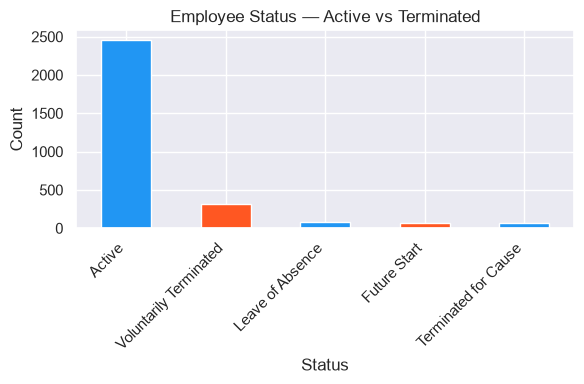

In [15]:
#ATTRITION COUNT
os.makedirs('charts', exist_ok=True)
sns.set_theme(style='darkgrid')

plt.figure(figsize=(6,4))
emp['EmployeeStatus'].value_counts().plot(kind='bar', color=['#2196F3','#FF5722'])
plt.title('Employee Status — Active vs Terminated')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/1_attrition_count.png')
plt.show()

#ATTRITION BY DEPARTMENT

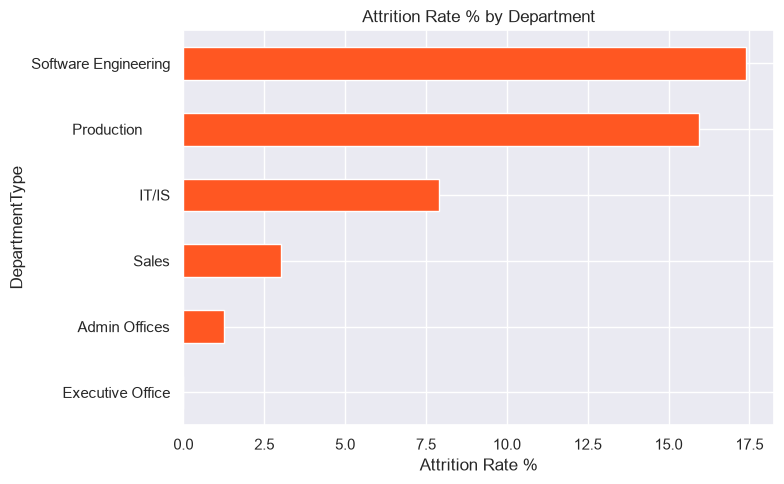

In [16]:
plt.figure(figsize=(8,5))
dept = emp.groupby('DepartmentType')['Attrition_Flag'].mean()*100
dept.sort_values().plot(kind='barh', color='#FF5722')
plt.title('Attrition Rate % by Department')
plt.xlabel('Attrition Rate %')
plt.tight_layout()
plt.savefig('charts/2_attrition_dept.png')
plt.show()

ATTRITION BY GENDER

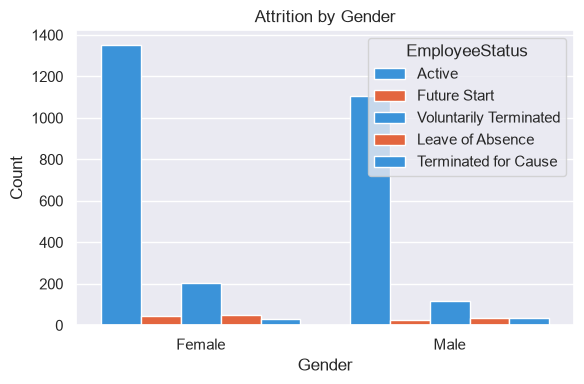

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=emp, x='GenderCode', hue='EmployeeStatus',
              palette=['#2196F3','#FF5722'])
plt.title('Attrition by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/3_gender_attrition.png')
plt.show()

ATTRITION BY AGE GROUP

In [18]:
# Check actual EmployeeStatus values


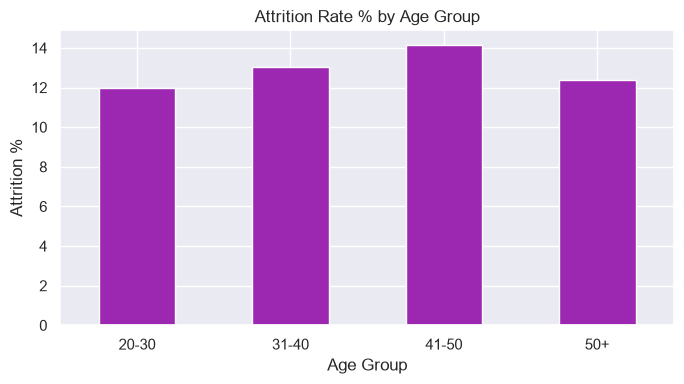

In [19]:
plt.figure(figsize=(7,4))
age_attr = emp.groupby('Age_Group')['Attrition_Flag'].mean()*100
age_attr.plot(kind='bar', color='#9C27B0')
plt.title('Attrition Rate % by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/4_age_attrition.png')
plt.show()

PERFORMANCE AND SCORE DISTRIBUTION

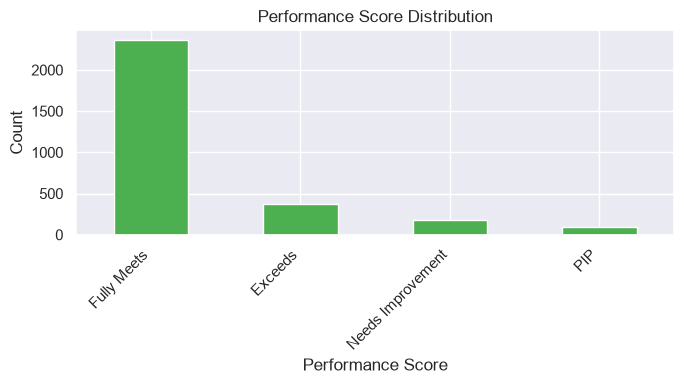

In [20]:
plt.figure(figsize=(7,4))
emp['Performance Score'].value_counts().plot(kind='bar', color='#4CAF50')
plt.title('Performance Score Distribution')
plt.xlabel('Performance Score')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/5_performance_dist.png')
plt.show()

PERFORMANE VS ATTRITION

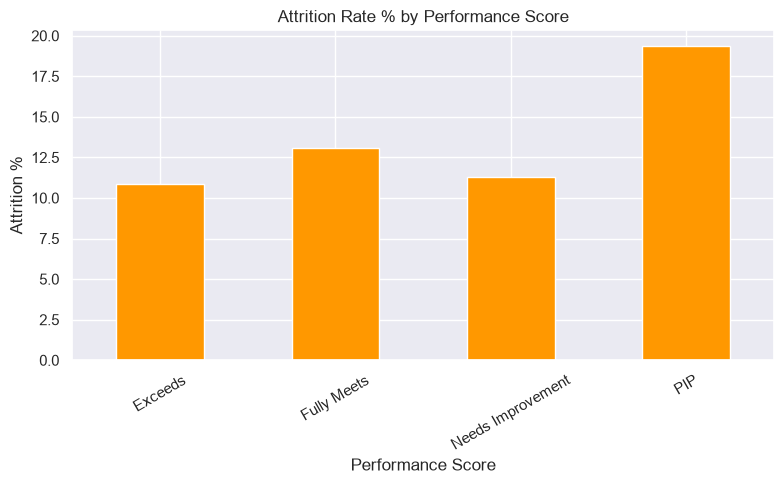

In [21]:
plt.figure(figsize=(8,5))
perf_attr = emp.groupby('Performance Score')['Attrition_Flag'].mean()*100
perf_attr.plot(kind='bar', color='#FF9800')
plt.title('Attrition Rate % by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Attrition %')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('charts/6_perf_attrition.png')
plt.show()

ENGAGEMENT SCORE DISTRIBUTION

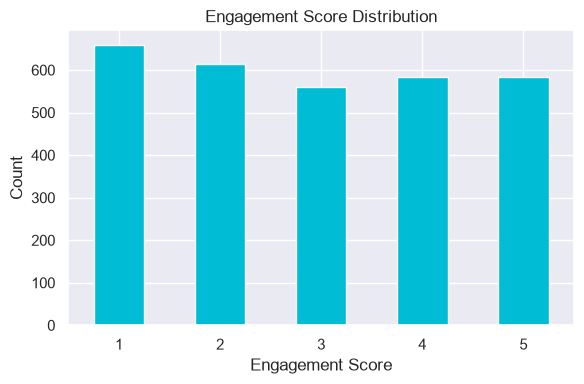

In [22]:
plt.figure(figsize=(6,4))
survey['Engagement Score'].value_counts().sort_index().plot(
    kind='bar', color='#00BCD4')
plt.title('Engagement Score Distribution')
plt.xlabel('Engagement Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/7_engagement_dist.png')
plt.show()

TRAINING OUTCOME

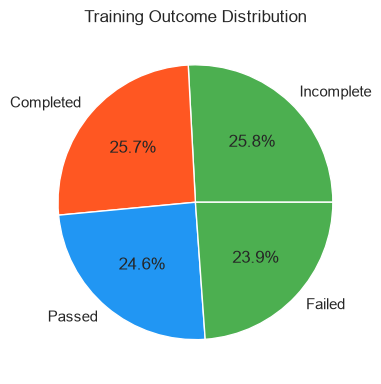

In [23]:
plt.figure(figsize=(6,4))
training['Training Outcome'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#4CAF50','#FF5722','#2196F3'])
plt.title('Training Outcome Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/8_training_outcome.png')
plt.show()

RECRUITMENT STATUS

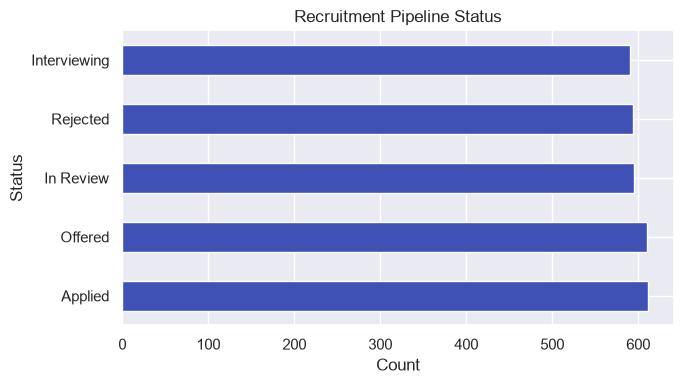

In [24]:
plt.figure(figsize=(7,4))
recruit['Status'].value_counts().plot(kind='barh', color='#3F51B5')
plt.title('Recruitment Pipeline Status')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('charts/9_recruitment_status.png')
plt.show()

TENURE VS ATTRITION

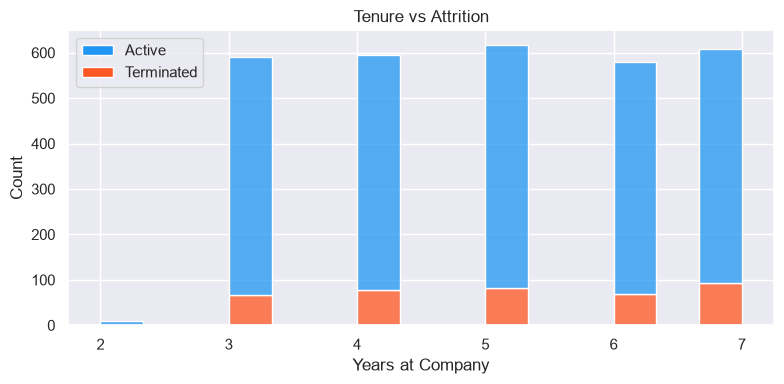

In [25]:
plt.figure(figsize=(8,4))
sns.histplot(data=emp, x='Tenure_Years', hue='Attrition_Flag',
             bins=15, palette={0:'#2196F3', 1:'#FF5722'},
             multiple='stack')
plt.title('Tenure vs Attrition')
plt.xlabel('Years at Company')
plt.ylabel('Count')

# Fix legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Active'),
                   Patch(facecolor='#FF5722', label='Terminated')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('charts/10_tenure_attrition.png')
plt.show()

SQL DATABASE IMPORT

In [16]:
from sqlalchemy import create_engine
import pandas as pd
import urllib

# Fresh engine
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=hr_analytics;"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    pool_pre_ping=True
)

# Test connection
try:
    with engine.connect() as conn:
        print("Connection successful!")
except Exception as e:
    print("Connection failed:", e)

Connection successful!


In [21]:
import pyodbc
import pandas as pd

# Load CSVs
df = pd.read_csv('data/cleaned_hr_data.csv')
recruit = pd.read_csv('data/cleaned_recruitment.csv')

# Fix dtypes
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

for col in recruit.columns:
    if recruit[col].dtype == 'object':
        recruit[col] = recruit[col].astype(str)
    else:
        recruit[col] = pd.to_numeric(recruit[col], errors='coerce').fillna(0)

# Connect
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=hr_analytics;"
    "Trusted_Connection=yes;"
)
cursor = conn.cursor()
print("Connected!")

Connected!


In [ ]:
df.head()
df.info()

NameError: name 'cleaned_df' is not defined

In [ ]:
recruit.info()

In [22]:
# Import hr_data
cursor.execute("DROP TABLE IF EXISTS hr_data")
cols = ', '.join([f'[{c}] NVARCHAR(255)' for c in df.columns])
cursor.execute(f"CREATE TABLE hr_data ({cols})")

batch = 200
for i in range(0, len(df), batch):
    chunk = df.iloc[i:i+batch]
    for _, row in chunk.iterrows():
        placeholders = ', '.join(['?'] * len(row))
        cursor.execute(
            f"INSERT INTO hr_data VALUES ({placeholders})",
            tuple(str(v) for v in row)
        )
conn.commit()
print(f"hr_data done — {len(df)} rows")

# Import recruitment
cursor.execute("DROP TABLE IF EXISTS recruitment")
cols2 = ', '.join([f'[{c}] NVARCHAR(255)' for c in recruit.columns])
cursor.execute(f"CREATE TABLE recruitment ({cols2})")

for i in range(0, len(recruit), batch):
    chunk = recruit.iloc[i:i+batch]
    for _, row in chunk.iterrows():
        placeholders = ', '.join(['?'] * len(row))
        cursor.execute(
            f"INSERT INTO recruitment VALUES ({placeholders})",
            tuple(str(v) for v in row)
        )
conn.commit()
print(f"recruitment done — {len(recruit)} rows")

cursor.close()
conn.close()
print("Both tables imported successfully!")

hr_data done — 3000 rows
recruitment done — 3000 rows
Both tables imported successfully!


In [44]:
import pandas as pd
from sqlalchemy import create_engine, types

# --- 1. SET UP SSMS CONNECTION ---
server = 'localhost\SQLEXPRESS'
database = 'hr_analytics'

connection_string = f'mssql+pyodbc://{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes'
engine = create_engine(connection_string)


# --- 2. IMPORT HR DATA ---
df_hr = pd.read_csv('C:\\Users\\DELL\\OneDrive\\Desktop\\HR-Analytics\\python\\data\\cleaned_hr_data.csv')

# Fix Attrition Flag (1 = Left, 0 = Active)
df_hr['Attrition_Flag'] = df_hr['TerminationType'].apply(lambda x: 0 if str(x).strip() == 'Unk' else 1)

# Dynamically map Python data types to SQL types for HR Data
dtype_hr = {}
for col in df_hr.columns:
    if df_hr[col].dtype == 'int64':
        dtype_hr[col] = types.INTEGER()
    elif df_hr[col].dtype == 'float64':
        dtype_hr[col] = types.FLOAT()
    else:
        dtype_hr[col] = types.NVARCHAR(length=255)

# Export to SSMS
df_hr.to_sql('hr_data', con=engine, if_exists='replace', index=False, dtype=dtype_hr)
print("✅ 'hr_data' exported successfully to localhost/hr_analytics!")


# --- 3. IMPORT RECRUITMENT DATA ---
df_rec = pd.read_csv('C:\\Users\\DELL\\OneDrive\\Desktop\\HR-Analytics\\python\\data\\cleaned_recruitment.csv')

# Dynamically map Python data types to SQL types for Recruitment Data
dtype_rec = {}
for col in df_rec.columns:
    if df_rec[col].dtype == 'int64':
        dtype_rec[col] = types.INTEGER()
    elif df_rec[col].dtype == 'float64':
        dtype_rec[col] = types.FLOAT()
    else:
        dtype_rec[col] = types.NVARCHAR(length=255)

# Export to SSMS
df_rec.to_sql('recruitment_data', con=engine, if_exists='replace', index=False, dtype=dtype_rec)
print("✅ 'recruitment_data' exported successfully to localhost/hr_analytics!")

✅ 'hr_data' exported successfully to localhost/hr_analytics!
✅ 'recruitment_data' exported successfully to localhost/hr_analytics!
